In [1]:
# UK Car Price Prediction - Machine Learning Model
## Task 3 - Model Training & Evaluation
### Best Model: Gradient Boosting (92.03% Accuracy)

In [2]:
!pip install pandas numpy matplotlib scikit-learn

In [3]:
import pandas as pd
df = pd.read_csv('uk_car_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 300 rows, 9 columns


In [4]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Age feature
df['Age'] = 2024 - df['Year']

le_brand = LabelEncoder()
le_fuel  = LabelEncoder()
le_trans = LabelEncoder()

df['Brand_Enc']        = le_brand.fit_transform(df['Brand'])
df['Fuel_Type_Enc']    = le_fuel.fit_transform(df['Fuel_Type'])
df['Transmission_Enc'] = le_trans.fit_transform(df['Transmission'])

print("=" * 55)
print("  FEATURE ENGINEERING COMPLETE")
print("=" * 55)
print(f"  Age feature added : 2024 - Year")
print(f"  Brand encoded     : {list(le_brand.classes_)}")
print(f"  Fuel encoded      : {list(le_fuel.classes_)}")
print(f"  Transmission enc  : {list(le_trans.classes_)}")

  FEATURE ENGINEERING COMPLETE
  Age feature added : 2024 - Year
  Brand encoded     : ['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mercedes', 'Nissan', 'Toyota', 'Vauxhall', 'Volkswagen']
  Fuel encoded      : ['Diesel', 'Electric', 'Hybrid', 'Petrol']
  Transmission enc  : ['Automatic', 'Manual']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Age', 'Engine_Size', 'Mileage', 'Owners',
            'Brand_Enc', 'Fuel_Type_Enc', 'Transmission_Enc']

X = df[features]
y = df['Price_GBP']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("=" * 55)
print("  TRAIN TEST SPLIT")
print("=" * 55)
print(f"  Training set : {X_train.shape[0]} rows")
print(f"  Testing set  : {X_test.shape[0]} rows")

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n" + "=" * 55)
print("  MODEL TRAINING & EVALUATION")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred,
                     'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n  {name}")
    print(f"    MAE  : £{mae:,.2f}")
    print(f"    RMSE : £{rmse:,.2f}")
    print(f"    R2   : {r2*100:.2f}%")

best_name = max(results, key=lambda x: results[x]['R2'])
best      = results[best_name]
print("\n" + "=" * 55)
print(f"  BEST MODEL : {best_name}")
print(f"  R2 Score   : {best['R2']*100:.2f}%")
print(f"  MAE        : £{best['MAE']:,.2f}")
print("=" * 55)

  TRAIN TEST SPLIT
  Training set : 240 rows
  Testing set  : 60 rows

  MODEL TRAINING & EVALUATION

  Linear Regression
    MAE  : £5,376.12
    RMSE : £6,438.04
    R2   : 43.72%

  Random Forest
    MAE  : £2,908.30
    RMSE : £3,573.69
    R2   : 82.66%

  Gradient Boosting
    MAE  : £1,983.68
    RMSE : £2,422.34
    R2   : 92.03%

  BEST MODEL : Gradient Boosting
  R2 Score   : 92.03%
  MAE        : £1,983.68


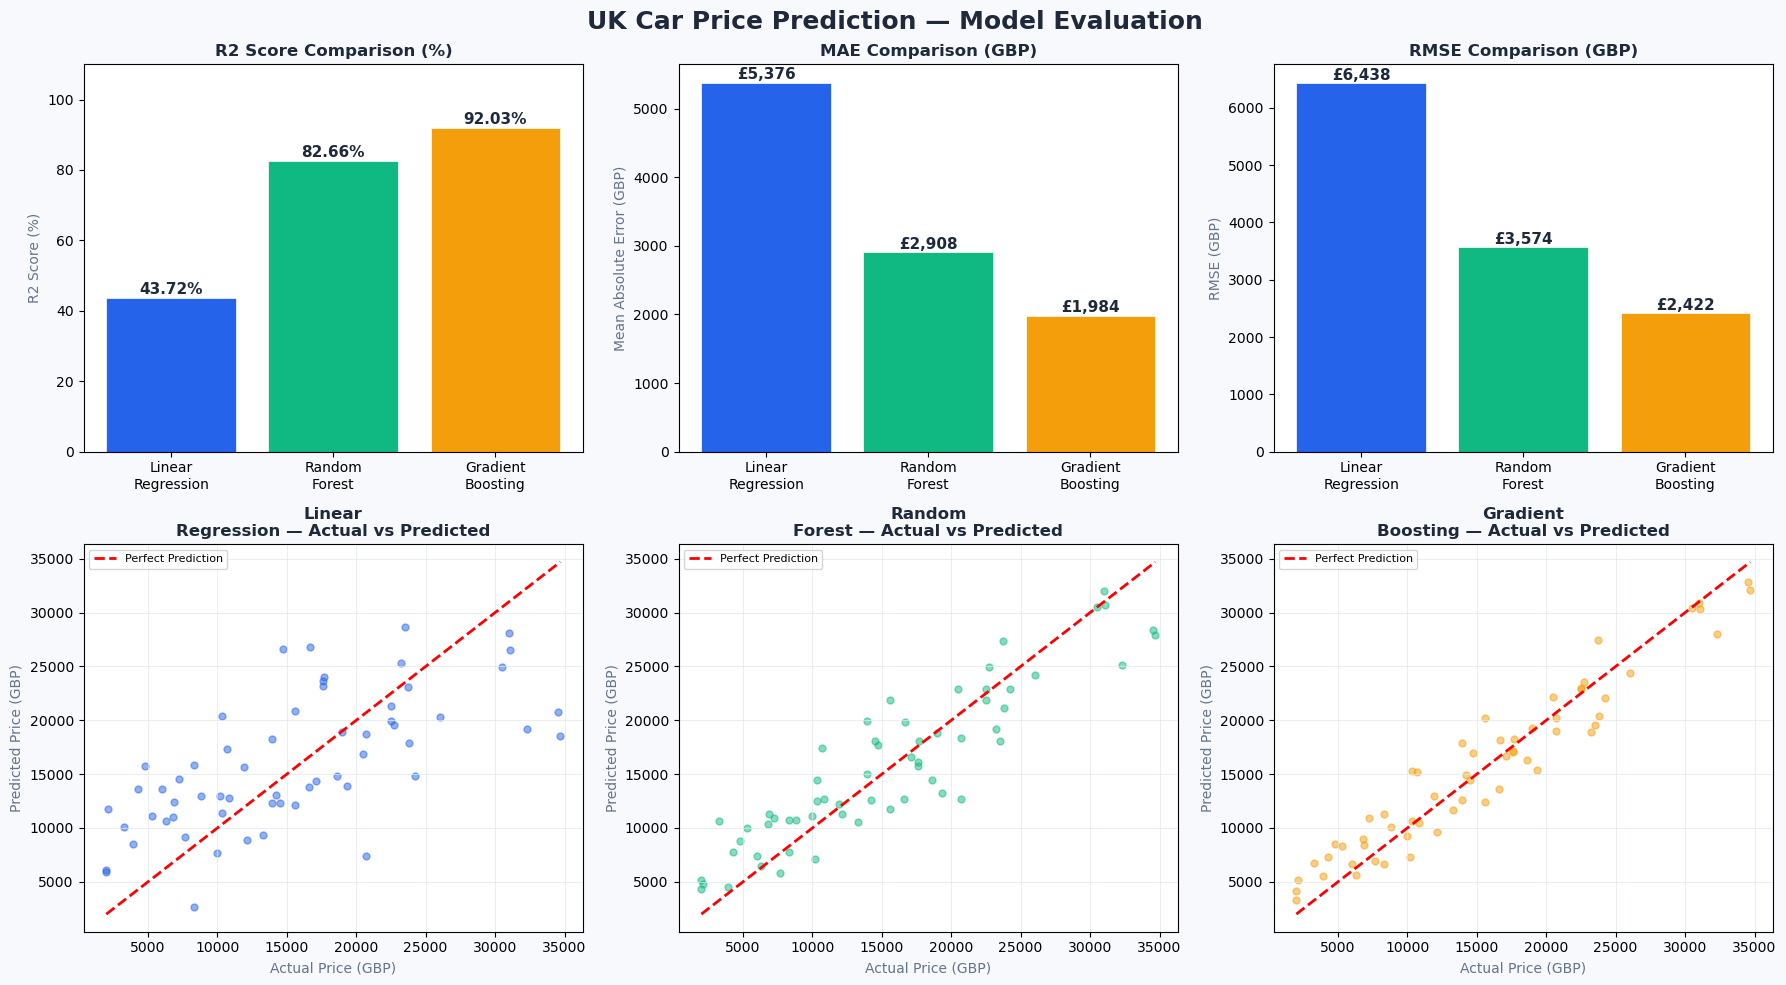

Model evaluation charts complete!


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#F7F9FC')
fig.suptitle('UK Car Price Prediction — Model Evaluation',
             fontsize=18, fontweight='bold', color='#1E293B')

model_names = list(results.keys())
short_names = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
colors_bar  = ['#2563EB', '#10B981', '#F59E0B']

# R2 Comparison
ax = axes[0, 0]
ax.set_facecolor('#FFFFFF')
r2_vals = [results[m]['R2'] * 100 for m in model_names]
bars = ax.bar(short_names, r2_vals, color=colors_bar,
              edgecolor='white', linewidth=0.5)
ax.set_title('R2 Score Comparison (%)', fontweight='bold', color='#1E293B')
ax.set_ylabel('R2 Score (%)', color='#64748B')
ax.set_ylim(0, 110)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.2f}%', ha='center', fontweight='bold',
            fontsize=11, color='#1E293B')

# MAE Comparison
ax = axes[0, 1]
ax.set_facecolor('#FFFFFF')
mae_vals = [results[m]['MAE'] for m in model_names]
bars2 = ax.bar(short_names, mae_vals, color=colors_bar,
               edgecolor='white', linewidth=0.5)
ax.set_title('MAE Comparison (GBP)', fontweight='bold', color='#1E293B')
ax.set_ylabel('Mean Absolute Error (GBP)', color='#64748B')
for bar, val in zip(bars2, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'£{val:,.0f}', ha='center', fontweight='bold',
            fontsize=11, color='#1E293B')

# RMSE Comparison
ax = axes[0, 2]
ax.set_facecolor('#FFFFFF')
rmse_vals = [results[m]['RMSE'] for m in model_names]
bars3 = ax.bar(short_names, rmse_vals, color=colors_bar,
               edgecolor='white', linewidth=0.5)
ax.set_title('RMSE Comparison (GBP)', fontweight='bold', color='#1E293B')
ax.set_ylabel('RMSE (GBP)', color='#64748B')
for bar, val in zip(bars3, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'£{val:,.0f}', ha='center', fontweight='bold',
            fontsize=11, color='#1E293B')

# Actual vs Predicted
for idx, (name, short) in enumerate(zip(model_names, short_names)):
    ax = axes[1, idx]
    ax.set_facecolor('#FFFFFF')
    y_pred = results[name]['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.5, color=colors_bar[idx], s=25)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect Prediction')
    ax.set_title(f'{short} — Actual vs Predicted',
                 fontweight='bold', color='#1E293B')
    ax.set_xlabel('Actual Price (GBP)', color='#64748B')
    ax.set_ylabel('Predicted Price (GBP)', color='#64748B')
    ax.legend(fontsize=8)
    ax.grid(True, color='#E2E8F0', linewidth=0.5)

plt.tight_layout()
plt.savefig('ml_model_results.png', dpi=150,
            bbox_inches='tight', facecolor='#F7F9FC')
plt.show()
print("Model evaluation charts complete!")

In [7]:
print("=" * 55)
print("  CAR PRICE PREDICTOR — SAMPLE PREDICTIONS")
print("=" * 55)

best_model = results[best_name]['model']

sample_cars = [
    {'Brand':'BMW',      'Year':2020, 'Fuel_Type':'Petrol',
     'Transmission':'Automatic', 'Engine_Size':2.0,
     'Mileage':30000, 'Owners':1},
    {'Brand':'Ford',     'Year':2018, 'Fuel_Type':'Diesel',
     'Transmission':'Manual',    'Engine_Size':1.5,
     'Mileage':55000, 'Owners':2},
    {'Brand':'Mercedes', 'Year':2022, 'Fuel_Type':'Hybrid',
     'Transmission':'Automatic', 'Engine_Size':2.5,
     'Mileage':10000, 'Owners':1},
    {'Brand':'Toyota',   'Year':2016, 'Fuel_Type':'Petrol',
     'Transmission':'Manual',    'Engine_Size':1.4,
     'Mileage':72000, 'Owners':2},
    {'Brand':'Nissan',   'Year':2021, 'Fuel_Type':'Electric',
     'Transmission':'Automatic', 'Engine_Size':1.0,
     'Mileage':15000, 'Owners':1},
]

for car in sample_cars:
    age   = 2024 - car['Year']
    b_enc = le_brand.transform([car['Brand']])[0]
    f_enc = le_fuel.transform([car['Fuel_Type']])[0]
    t_enc = le_trans.transform([car['Transmission']])[0]
    X_new = pd.DataFrame([[age, car['Engine_Size'], car['Mileage'],
                           car['Owners'], b_enc, f_enc, t_enc]],
                         columns=features)
    pred = best_model.predict(X_new)[0]
    print(f"  {car['Brand']:<12} {car['Year']}  "
          f"{car['Fuel_Type']:<10} {car['Transmission']:<12}"
          f"Predicted: £{pred:,.0f}")

print("\n" + "=" * 55)
print("  TASK 3 — ML MODEL COMPLETE")
print("=" * 55)

  CAR PRICE PREDICTOR — SAMPLE PREDICTIONS
  BMW          2020  Petrol     Automatic   Predicted: £30,867
  Ford         2018  Diesel     Manual      Predicted: £10,575
  Mercedes     2022  Hybrid     Automatic   Predicted: £38,410
  Toyota       2016  Petrol     Manual      Predicted: £11,865
  Nissan       2021  Electric   Automatic   Predicted: £23,994

  TASK 3 — ML MODEL COMPLETE
